<a href="https://colab.research.google.com/github/sidchaini/Death-and-Taxes/blob/main/willow-and-sid/20260212_DeathAndTaxes_Prototype_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authors: Willow and Sid
Date: 2026-02-12

Rough description of this notebook:
We're trying to reproduce the patching from https://arxiv.org/abs/2510.17959 but some questions are:
- How do we patch variable lengths
- Making it work on a non-uniform grid, etc.

For now, working with Willow's clean dataset of spectra from ABC-SN. And because they're on a grid, we can only consider the same no. of patches. This exact approach won't work for WISERep, but exploring methodology for now.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import sys
from copy import deepcopy

In [ ]:
%%capture
!git clone https://github.com/FoxFortino/ABC-SN.git
sys.path.insert(0, "ABC-SN/code")
import data_preparation as dp

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import numba
from keras.utils import pad_sequences
import keras
import keras_hub

!pip install icecream
from icecream import ic

In [ ]:
df_data = pd.read_parquet("ABC-SN/data/original_resolution_parquet/df_preprocessed.parquet")

In [ ]:
# 0: index
# 1: wvl
# 2: flux_columns
# 3: metadata_columns
# 4: df_fluxes
# 5: df_metadata
# 6: data
result = dp.extract_dataframe(df_data)
index = result[0]
wvl = result[1]
flux_columns = result[2]
metadata_columns = result[3]
df_fluxes = result[4]
df_metadata = result[5]
data = result[6]

In [ ]:
padding_mask = wvl <= 4500
padding_mask |= wvl >= 7000
data_nopad = data[:, ~padding_mask]
wvl_nopad = wvl[~padding_mask]

In [ ]:
data_nopad.shape

(4013, 327)

In [ ]:
wvl_nopad.shape

(327,)

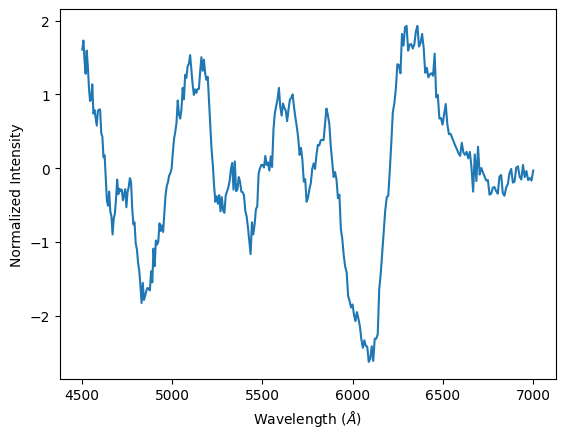

In [ ]:
i = 0
# plt.plot(wvl, data[i])
plt.plot(wvl_nopad, data_nopad[i], label="Original SN Spectrum")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"Wavelength ($\AA$)")
plt.show()

In [ ]:
data_nopad.shape

(4013, 327)

In [ ]:
def patch(wvl, input, patch_size=32):
    assert input.ndim == 1
    assert wvl.size == input.size
    length = input.size
    num_patches = int(np.ceil(length / patch_size))

    patched_input = deepcopy(input)
    patched_wvl = deepcopy(wvl)


    num_addedzeros = num_patches * patch_size - length

    patched_input = list(patched_input)
    patched_wvl = list(patched_wvl)

    patched_input.extend([0.]*num_addedzeros)
    patched_wvl.extend([0.]*num_addedzeros)

    patched_input = np.reshape(patched_input, (num_patches, patch_size))
    patched_wvl = np.reshape(patched_wvl, (num_patches, patch_size))
    return patched_wvl, patched_input

In [ ]:
patch_size = 32

patched_spectra = []
patched_wvls = []
for spectrum in data_nopad:
    wvl_copy = deepcopy(wvl_nopad)
    patched_wvl, patched_spectrum = patch(wvl_copy, spectrum, patch_size=patch_size)

    patched_wvls.append(patched_wvl)
    patched_spectra.append(patched_spectrum)

print(len(patched_spectra), len(patched_wvls))

patched_spectra = pad_sequences(patched_spectra, dtype=float, padding="post")
patched_wvls = pad_sequences(patched_wvls, dtype=float, padding="post")
patched_spectra.shape, patched_wvls.shape

4013 4013


((4013, 11, 32), (4013, 11, 32))

In [ ]:
patched_spectra = patched_spectra.reshape(-1, 32)
patched_wvls = patched_wvls.reshape(-1, 32)
patched_spectra.shape, patched_wvls.shape

((44143, 32), (44143, 32))

In [ ]:
max_omega = 10_000
min_omega = 1

embedding_dimension = 48
PE_omegas = np.logspace(
    (2 * np.pi) / min_omega,
    (2 * np.pi) / max_omega,
    num=embedding_dimension)
PE_omegas.shape

(48,)

In [ ]:
def make_PE(patched_wvl, patch_size, embedding_dimension):
    PE = np.zeros((patch_size, embedding_dimension))

    for i in range(patch_size):
        if i % 2 == 0:
            PE[i] = np.sin(PE_omegas * patched_wvl[i])
        else:
            PE[i] = np.cos(PE_omegas * patched_wvl[i])
    return PE

patched_wvls.shape
PE_i = make_PE(patched_wvls[0], patch_size, embedding_dimension)
PE_i.shape

(32, 48)

In [ ]:
PE_arr = []
for patched_wvl in patched_wvls:
    PE_arr.append(make_PE(patched_wvl, patch_size, embedding_dimension))
PE = np.array(PE_arr)
PE.shape

(44143, 32, 48)

In [ ]:
patched_spectra.shape, patched_wvls.shape, PE.shape

((44143, 32), (44143, 32), (44143, 32, 48))

In [ ]:
patched_spectra = patched_spectra[:, :, None]
patched_spectra.shape

(44143, 32, 1)

In [ ]:
def make_encoder(input_shape, input_shape_PE, embedding_dimension):
    inputs_PE = keras.Input(shape=input_shape_PE)
    inputs = keras.Input(shape=input_shape)

    embed = keras.layers.Conv1D(embedding_dimension, 1)

    x = embed(inputs)
    x += inputs_PE

    x = keras_hub.layers.TransformerEncoder(512, 8)(x)
    LS = keras.layers.GlobalMaxPooling1D(data_format="channels_first", name="LS")(x)
    LS = keras.layers.Reshape((LS.shape[1], 1))(LS)
    x = embed(LS)
    x += inputs_PE
    x = keras_hub.layers.TransformerEncoder(512, 8)(x)

    x = keras.layers.Conv1D(1, 1)(x)




    model = keras.Model([inputs, inputs_PE], x)
    return model

input_shape = patched_spectra.shape[1:]
input_shape_PE = PE.shape[1:]
input_shape, input_shape_PE

((32, 1), (32, 48))

In [ ]:
model = make_encoder(input_shape, input_shape_PE, embedding_dimension)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 32, 48)    │         96 │ input_layer_1[0]… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 32, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 48)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 32, 48)    │     59,312 │ add[0][0]         │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LS                  │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 1)     │          0 │ LS[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 48)    │          0 │ conv1d[1][0],     │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 32, 48)    │     59,312 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 1)     │         49 │ transformer_enco… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 118,769 (463.94 KB)

 Trainable params: 118,769 (463.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="Adam",
    loss="mse",
)
model.fit(
    [patched_spectra, PE],
    patched_spectra,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.1549
Epoch 2/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0022
Epoch 3/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0017
Epoch 4/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015
Epoch 5/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0015
Epoch 6/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0013
Epoch 7/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 7.4680e-04
Epoch 8/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0010
Epoch 9/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.7731e-04
Epoch 10/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 9.8791e-04


In [ ]:
predicted_patches = model.predict([patched_spectra, PE])
predicted_patches.shape

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


(44143, 32, 1)

In [ ]:
spec1 = patched_spectra.reshape(-1, 11, 32)
Pred1 = predicted_patches.reshape(-1, 11, 32)
spec1.shape, Pred1.shape

((4013, 11, 32), (4013, 11, 32))

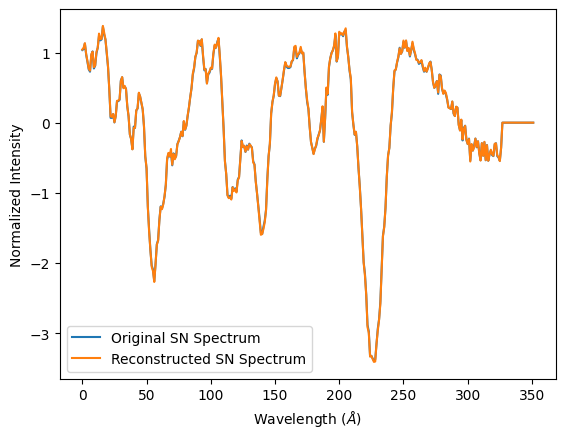

In [ ]:
i = 2500
plt.plot(spec1[i].reshape(-1), label="Original SN Spectrum")
plt.plot(Pred1[i].reshape(-1), label="Reconstructed SN Spectrum")

plt.ylabel("Normalized Intensity")
plt.xlabel(r"Wavelength ($\AA$)")

plt.legend()
plt.show()

In [ ]:
LS_model = keras.Model(model.input, model.get_layer("LS").output)
LS_model

<Functional name=functional_1, built=True>

In [ ]:
LS_model.predict

<bound method JAXTrainer.predict of <Functional name=functional_1, built=True>>

In [ ]:
pred_LS = LS_model.predict([patched_spectra, PE])

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Now we have the latent space from the middle of the autoencoder and we need to get the SN subtype ID for each patch. Get all of the patches corresponding to each subtype ID and see if they are self similar?

In [ ]:
df_data["SN Subtype"]

,SN Subtype
SN Name,
sn2008ar,Ia-norm
sn2008ar,Ia-norm
sn2008ar,Ia-norm
sn2008ar,Ia-norm
sn2008ar,Ia-norm
...,...
sn2007uy,Ib-pec
sn2007uy,Ib-pec
sn2007uy,Ib-pec


/tmp/ipython-input-290/1448533420.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subtype = df_data["SN Subtype"][i//11]
/tmp/ipython-input-290/1448533420.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phase = df_data["Spectral Phase"][i//11]


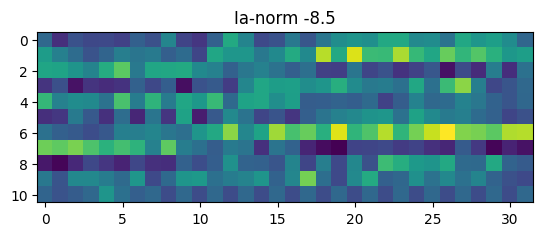

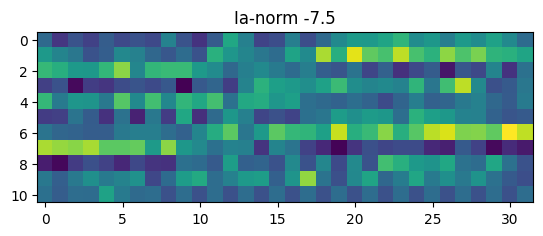

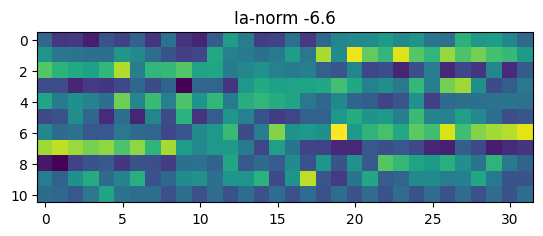

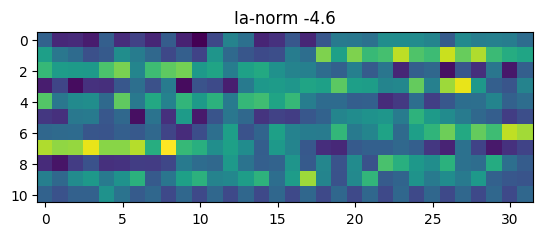

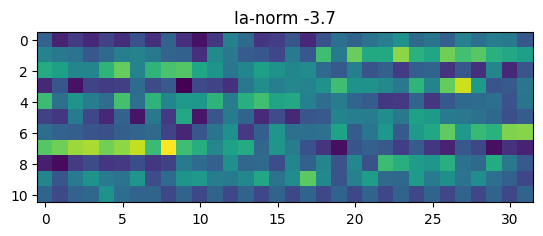

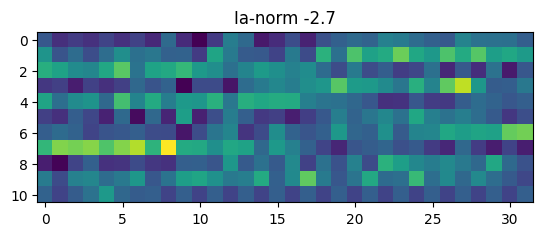

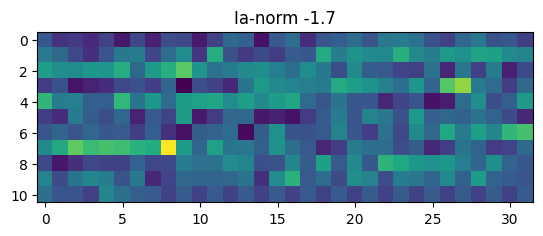

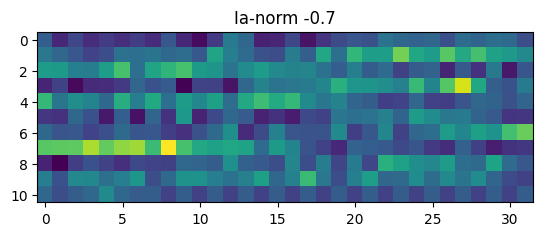

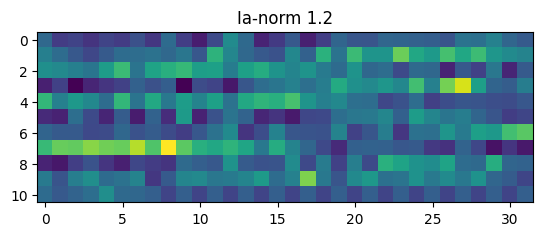

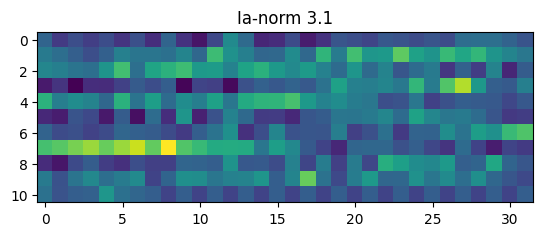

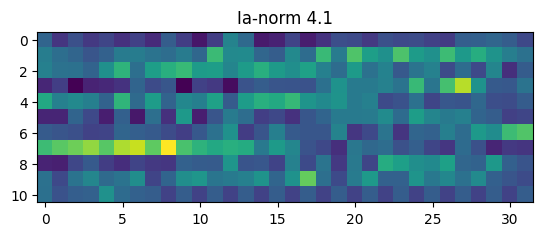

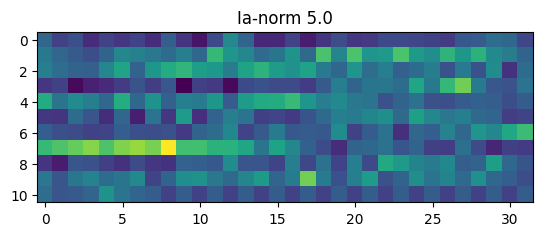

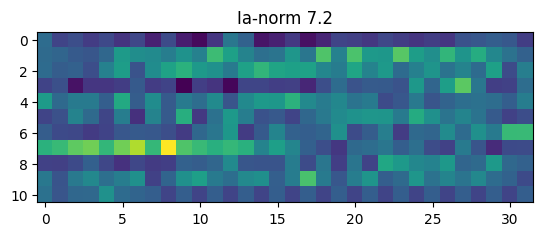

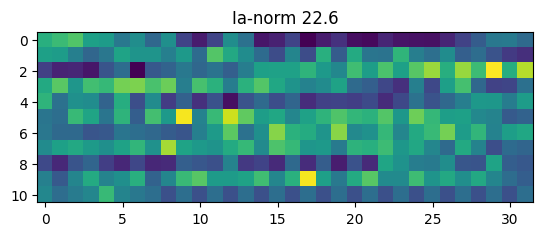

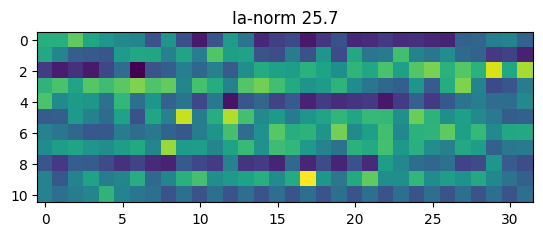

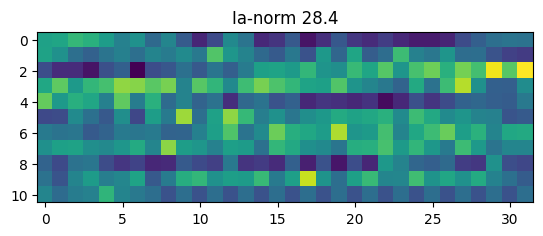

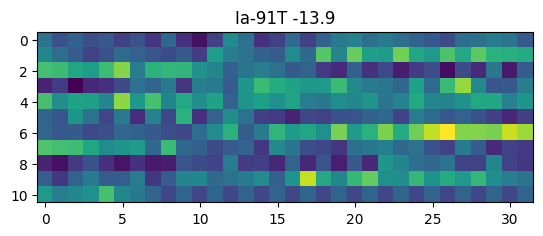

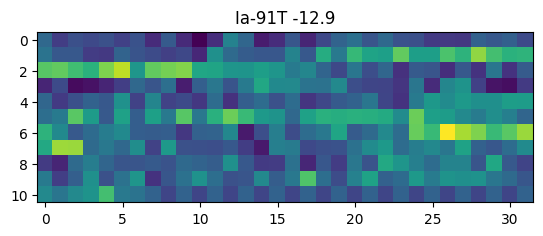

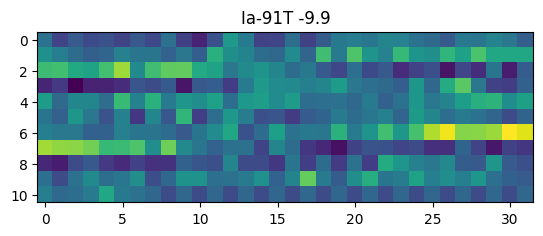

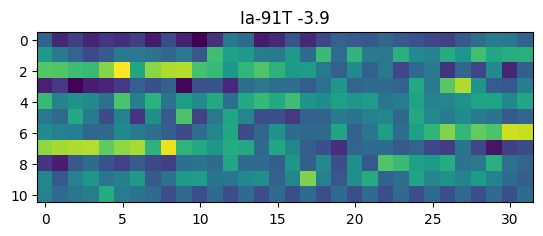

In [ ]:
 for i in range(0, pred_LS.shape[0], 11):
    subtype = df_data["SN Subtype"][i//11]
    phase = df_data["Spectral Phase"][i//11]
    pred_LS.shape
    plt.title(f"{subtype} {phase}")
    plt.imshow(pred_LS[i:i+11])
    plt.show()
    if i >= 200: break